In [1]:
import os
os.environ["TQDM_DISABLE"] = "1"

from unittest.mock import MagicMock
import sys
sys.modules['tqdm.notebook'] = MagicMock()
sys.modules['tqdm.auto'] = MagicMock()

In [2]:
from pathlib import Path
from IPython.display import display


from src import (
    load_data,
    explore_data,
    split_data,
    EDA,
    select_model,
    compare_ensembles,
    tune_hyperparameters,
    evaluate_model,
    important_features,
    feature_selection,
    tag_to_comment
)

In [3]:
ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "ACME-HappinessSurvey2020.csv"

In [4]:
df = load_data(DATA_PATH)

In [5]:
explore_data(df)

     Y  X1  X2  X3  X4  X5  X6
0    0   3   3   3   4   2   4
1    0   3   2   3   5   4   3
2    1   5   3   3   3   3   5
3    0   5   4   3   3   3   5
4    0   5   4   3   3   3   5
121  1   5   2   3   4   4   3
122  1   5   2   3   4   2   5
123  1   5   3   3   4   4   5
124  0   4   3   3   4   4   5
125  0   5   3   2   5   5   5
Shape of the dataset : (126, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


In [6]:
SEED = 7964
X_train, X_test, y_train, y_test = split_data(df, "Y", SEED, test_size=0.2)

Size of the training set: 100
Size of the testing set: 26


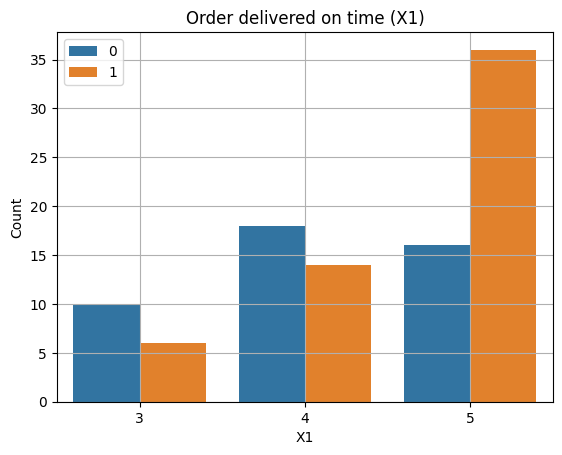

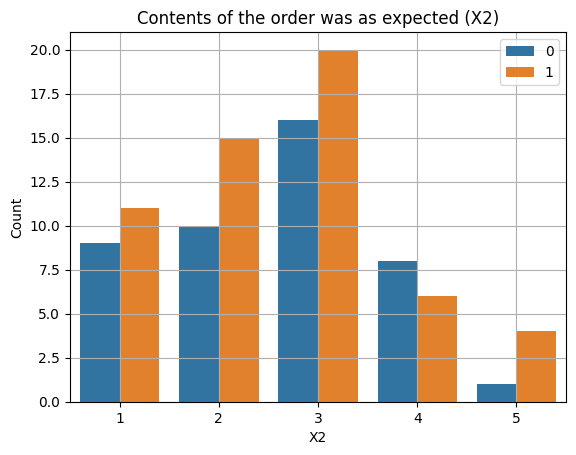

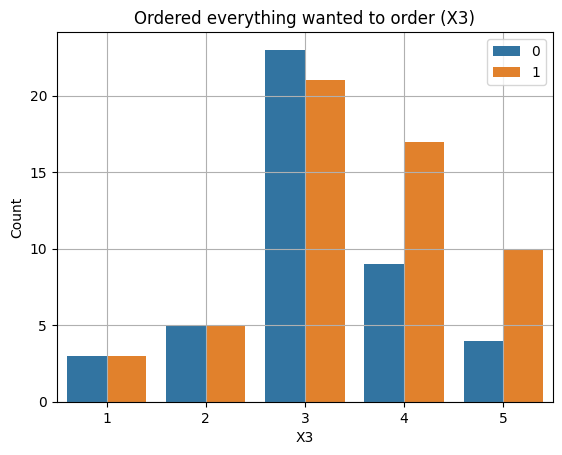

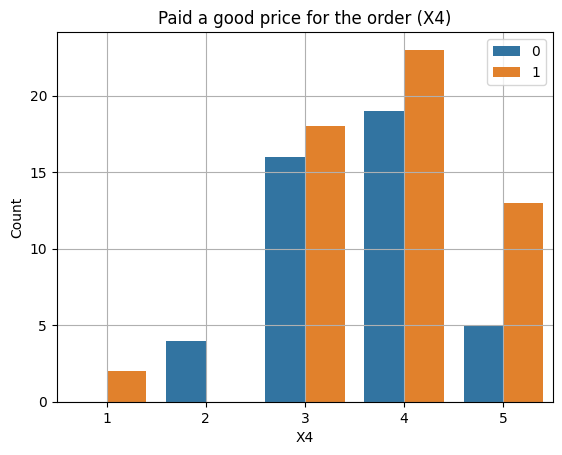

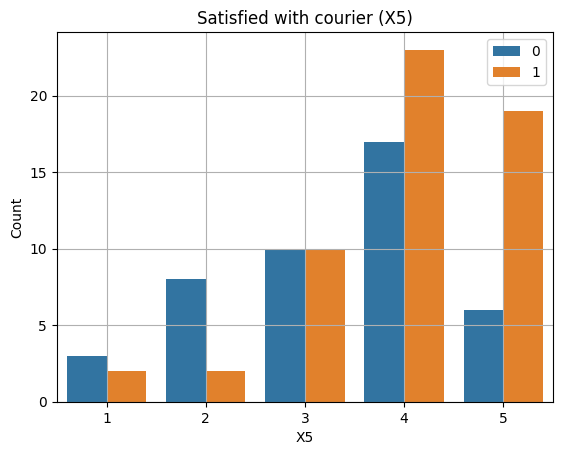

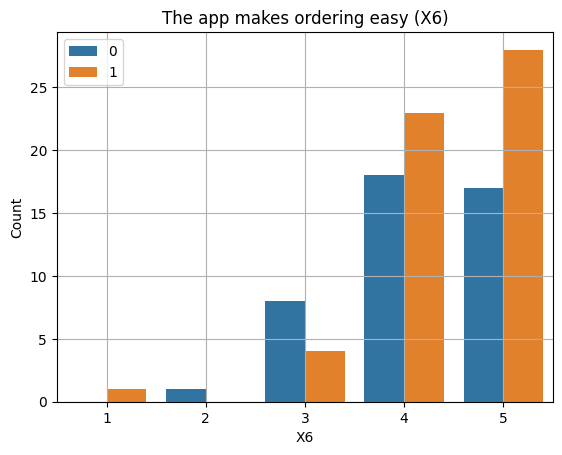

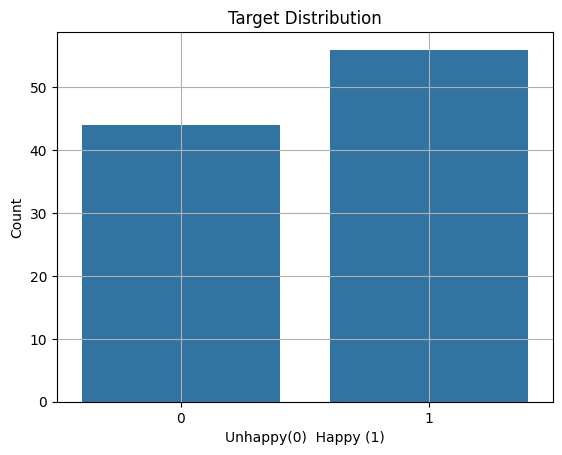

In [7]:
EDA(X_train, y_train)

In [8]:
# LazyPredict (exploration only, uses X_test causing a data leakage)
models, _ = select_model(X_train, X_test, y_train, y_test)
display(models)

Empty DataFrame
Columns: [Accuracy, Balanced Accuracy, ROC AUC, F1 Score, minority_recall, Time Taken]
Index: []


ValueError: attempt to get argmax of an empty sequence

        Model  Minority_Recall
         LGBM             0.54
Random Forest             0.41
   ExtraTrees             0.36
       Voting             0.36
          KNN             0.34
     Stacking             0.12


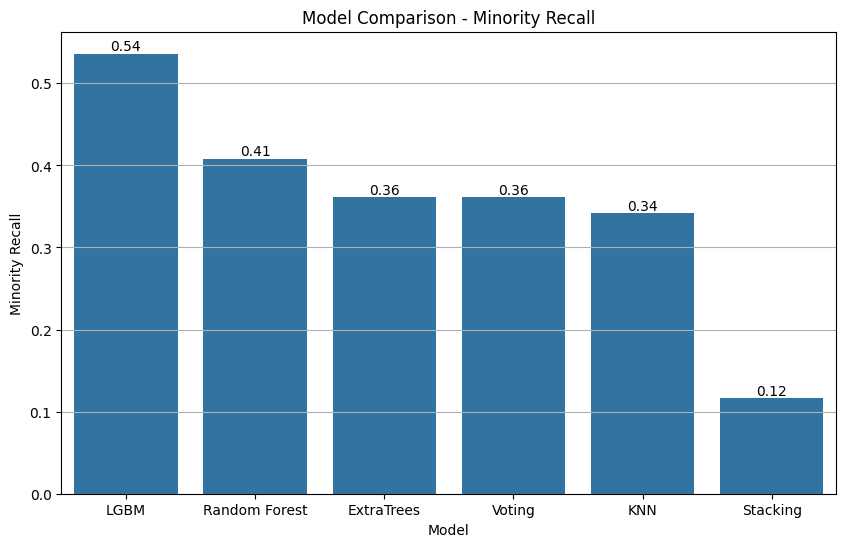

In [ ]:
fitted_models, results_df = compare_ensembles(
    X_train, y_train, X_test, y_test, seed=SEED, cv=5
)
results_df

In [ ]:
# Hyperopt tuning for LGBM
best_model, best_params, best_score = tune_hyperparameters(X_train, y_train, SEED)

100%|██████████| 50/50 [00:03<00:00, 14.80trial/s, best loss: -0.6972222222222222]
Best Parameters: {'n_estimators': 50, 'max_depth': 7, 'learning_rate': np.float64(0.08532963348673303), 'num_leaves': 10, 'min_child_samples': 15, 'subsample': np.float64(0.7985039259694021), 'colsample_bytree': np.float64(0.7065582777394013)}
Best Score: 0.7


In [14]:
# Final evaluation of tuned LGBM on test set
print(evaluate_model(best_model, X_test, y_test))

              precision    recall  f1-score   support

           0       0.65      0.85      0.73        13
           1       0.78      0.54      0.64        13

    accuracy                           0.69        26
   macro avg       0.71      0.69      0.68        26
weighted avg       0.71      0.69      0.68        26



In [16]:
feature_df = important_features(X_train, best_model, tag_to_comment)
feature_df

,Feature,Description,Importance
0,X5,Satisfied with courier,44
1,X1,Order delivered on time,38
2,X2,Contents of the order was as expected,30
3,X4,Paid a good price for the order,27
4,X3,Ordered everything wanted to order,21
5,X6,The app makes ordering easy,16


In [17]:
clf_fs, selected_features, removed_features, test_accuracy = feature_selection(
    X_train, y_train, X_test, y_test, best_params, SEED
)

test_accuracy, removed_features

(0.615, ['X3', 'X4', 'X6'])

In [18]:
print("Questions that can be removed from the survey:")
for f in removed_features:
    print("-", tag_to_comment.get(f, f))

Questions that can be removed from the survey:
- Ordered everything wanted to order
- Paid a good price for the order
- The app makes ordering easy
